#Project Title: Sales Forecasting, Consumer Behaviour Analysis, and Demand Prediction for ABC Ice Creams Using Business Intelligence and Machine Learning

by Vini Lunia

#Project Objectives
1. Analyse historical sales patterns of ABC Ice Creams.
2. Identify key factors influencing ice cream sales.
3. Study customer purchasing behaviour and preferences.
4. Develop machine learning models for sales forecasting.
5. Predict future demand across products and seasons.
6. Provide data-driven recommendations for business growth.

In [36]:
# ============================================================
#🍦📊ABC ICE CREAMS Sales analysis
# SALES FORECASTING & BUSINESS INTELLIGENCE PROJECT
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
print("""
BUSINESS PROBLEM

ABC Ice Creams wants to forecast future sales to improve:

1. Production Planning
2. Inventory Management
3. Demand Forecasting
4. Regional Expansion
5. Marketing Campaign Planning

KEY FACTORS AFFECTING SALES

• Temperature
• Season
• Festivals
• Weekends
• Product Preferences
• Urban vs Rural Demand
• Time of Day

EXPECTED PATTERNS

• Higher sales during summer
• Festival spikes
• Higher urban demand
• Evening purchase peaks
• Weekend sales growth
""")


BUSINESS PROBLEM

ABC Ice Creams wants to forecast future sales to improve:

1. Production Planning
2. Inventory Management
3. Demand Forecasting
4. Regional Expansion
5. Marketing Campaign Planning

KEY FACTORS AFFECTING SALES

• Temperature
• Season
• Festivals
• Weekends
• Product Preferences
• Urban vs Rural Demand
• Time of Day

EXPECTED PATTERNS

• Higher sales during summer
• Festival spikes
• Higher urban demand
• Evening purchase peaks
• Weekend sales growth



In [3]:
np.random.seed(42)

dates = pd.date_range(
    start='2022-01-01',
    end='2025-12-31',
    freq='D'
)

products = [
    'Vanilla',
    'Chocolate',
    'Strawberry',
    'Butterscotch',
    'Coffee'
]

data = []

for date in dates:

    month = date.month

    if month in [3,4,5,6]:
        season = "Summer"
        temp = np.random.normal(38,3)

    elif month in [7,8,9]:
        season = "Monsoon"
        temp = np.random.normal(29,2)

    else:
        season = "Winter"
        temp = np.random.normal(22,3)

    day_type = "Weekend" if date.weekday() >=5 else "Weekday"

    location = np.random.choice(
        ['Urban','Rural'],
        p=[0.7,0.3]
    )

    time_slot = np.random.choice(
        ['Morning','Afternoon','Evening','Night'],
        p=[0.15,0.30,0.40,0.15]
    )

    festivals = [
        "Diwali",
        "Holi",
        "Navratri",
        "Christmas",
        "Summer Vacation",
        "None"
    ]

    event = np.random.choice(
        festivals,
        p=[0.03,0.03,0.03,0.02,0.08,0.81]
    )

    for product in products:

        base_units = 80

        base_units += (temp-25)*3

        if season=="Summer":
            base_units += 40

        if day_type=="Weekend":
            base_units += 20

        if location=="Urban":
            base_units += 25

        if event!="None":
            base_units += 35

        if time_slot=="Evening":
            base_units += 30

        product_factor = {
            'Vanilla':1.00,
            'Chocolate':1.20,
            'Strawberry':0.90,
            'Butterscotch':1.10,
            'Coffee':0.80
        }

        units = int(
            max(
                10,
                np.random.normal(
                    base_units*product_factor[product],
                    15
                )
            )
        )

        price = {
            'Vanilla':40,
            'Chocolate':50,
            'Strawberry':45,
            'Butterscotch':55,
            'Coffee':60
        }

        sales = units * price[product]

        data.append([
            date,
            month,
            season,
            temp,
            day_type,
            event,
            time_slot,
            location,
            product,
            units,
            sales
        ])

columns = [
    'Date',
    'Month',
    'Season',
    'Temperature',
    'DayType',
    'Event',
    'TimeSlot',
    'LocationType',
    'Product',
    'UnitsSold',
    'Sales'
]

df = pd.DataFrame(data, columns=columns)

print(df.shape)
df.head()

(7305, 11)


,Date,Month,Season,Temperature,DayType,Event,TimeSlot,LocationType,Product,UnitsSold,Sales
0,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Vanilla,158,6320
1,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Chocolate,196,9800
2,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Strawberry,159,7155
3,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Butterscotch,167,9185
4,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Coffee,120,7200


In [4]:
df.to_csv(
    "ABC_IceCream_Sales.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [5]:
print(df.shape)

df.info()

df.head()

(7305, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          7305 non-null   datetime64[ns]
 1   Month         7305 non-null   int64         
 2   Season        7305 non-null   object        
 3   Temperature   7305 non-null   float64       
 4   DayType       7305 non-null   object        
 5   Event         7305 non-null   object        
 6   TimeSlot      7305 non-null   object        
 7   LocationType  7305 non-null   object        
 8   Product       7305 non-null   object        
 9   UnitsSold     7305 non-null   int64         
 10  Sales         7305 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 627.9+ KB


,Date,Month,Season,Temperature,DayType,Event,TimeSlot,LocationType,Product,UnitsSold,Sales
0,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Vanilla,158,6320
1,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Chocolate,196,9800
2,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Strawberry,159,7155
3,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Butterscotch,167,9185
4,2022-01-01,1,Winter,23.490142,Weekend,Summer Vacation,Evening,Rural,Coffee,120,7200


In [6]:
df.isnull().sum()

,0
Date,0
Month,0
Season,0
Temperature,0
DayType,0
Event,0
TimeSlot,0
LocationType,0
Product,0
UnitsSold,0


In [7]:
df.describe()

,Date,Month,Temperature,UnitsSold,Sales
count,7305,7305.000000,7305.000000,7305.000000,7305.000000
mean,2024-01-01 00:00:00,6.522930,29.150416,147.711431,7356.111567
min,2022-01-01 00:00:00,1.000000,13.211654,19.000000,1125.000000
25%,2023-01-01 00:00:00,4.000000,23.121511,108.000000,5240.000000
50%,2024-01-01 00:00:00,7.000000,28.455811,140.000000,6985.000000
75%,2024-12-31 00:00:00,10.000000,35.902090,182.000000,9000.000000
max,2025-12-31 00:00:00,12.000000,46.351332,333.000000,17875.000000
std,NaN,3.448939,7.280827,53.059646,2782.486280


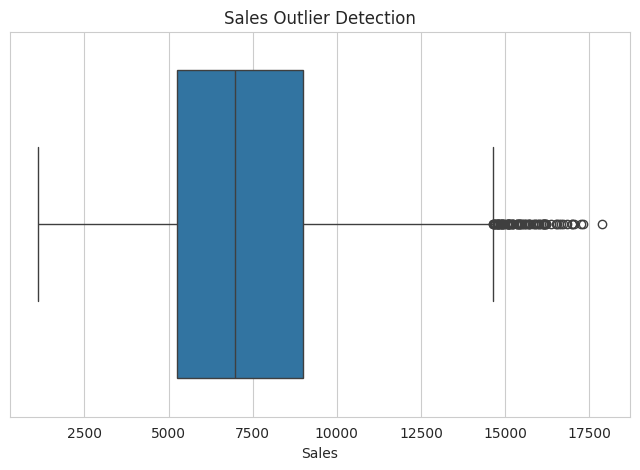

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Outlier Detection")
plt.show()

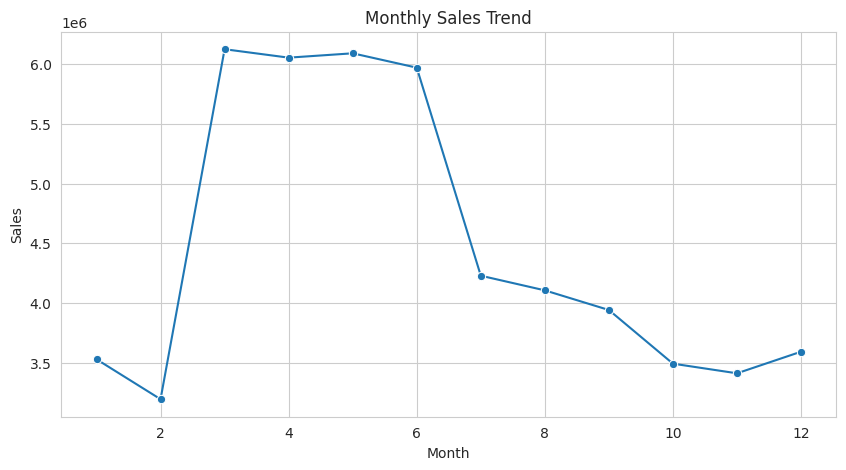

In [35]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.show()

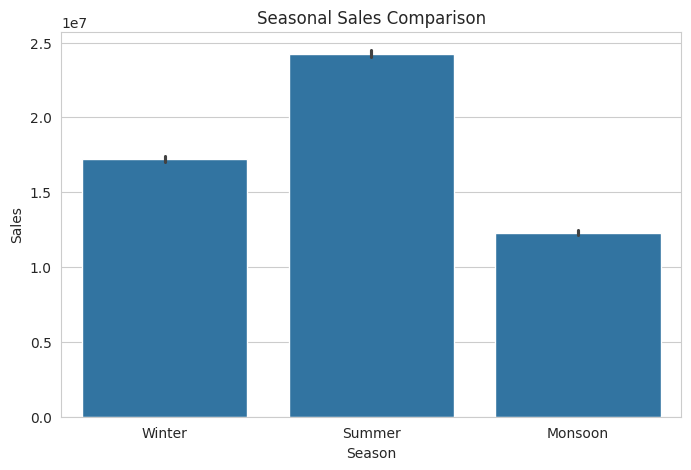

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Sales',
    estimator=np.sum
)

plt.title("Seasonal Sales Comparison")
plt.show()

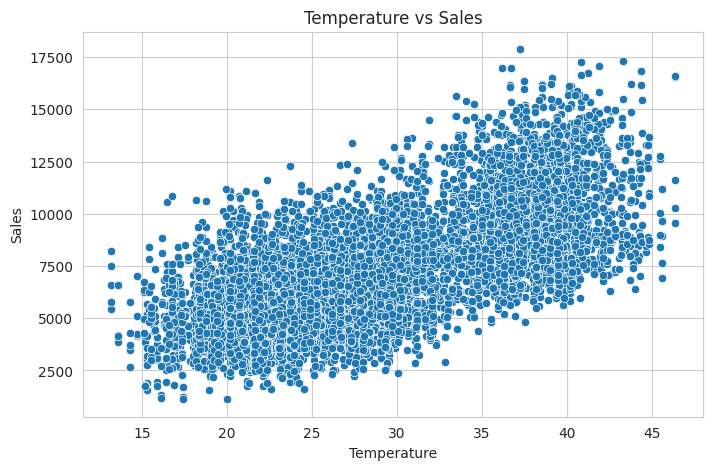

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Temperature',
    y='Sales'
)

plt.title("Temperature vs Sales")
plt.show()

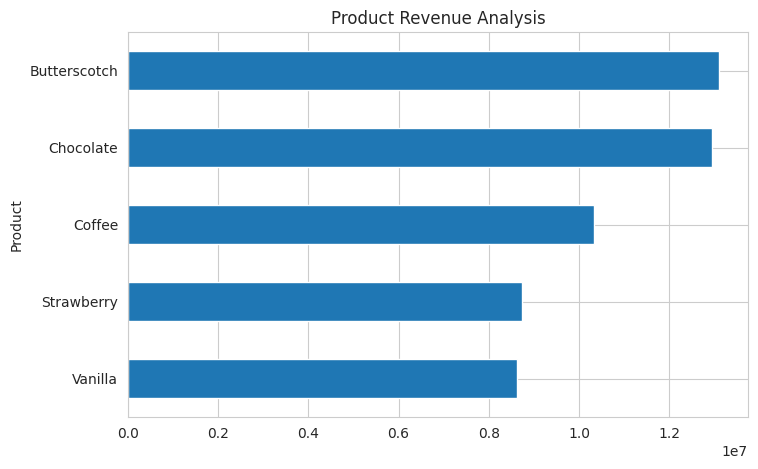

In [12]:
product_sales = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values()
)

product_sales.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Product Revenue Analysis")
plt.show()

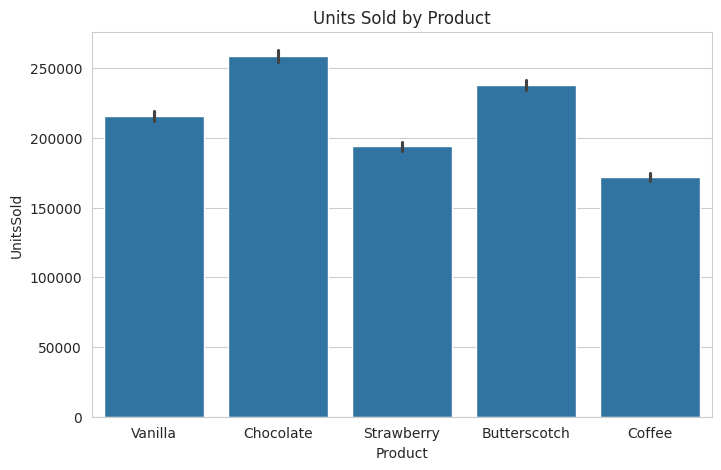

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Product',
    y='UnitsSold',
    estimator=np.sum
)

plt.title("Units Sold by Product")
plt.show()

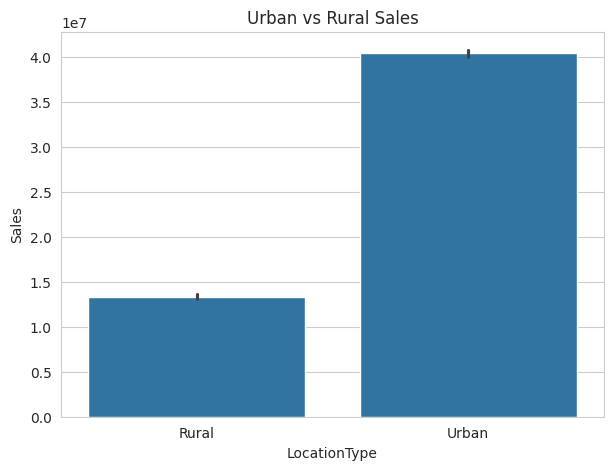

In [14]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='LocationType',
    y='Sales',
    estimator=np.sum
)

plt.title("Urban vs Rural Sales")
plt.show()

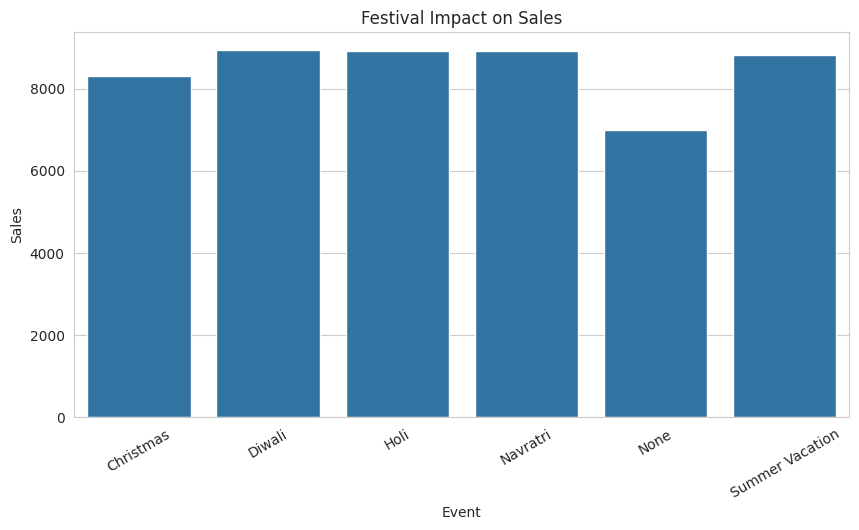

In [15]:
festival_sales = (
    df.groupby('Event')['Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=festival_sales,
    x='Event',
    y='Sales'
)

plt.xticks(rotation=30)

plt.title("Festival Impact on Sales")
plt.show()

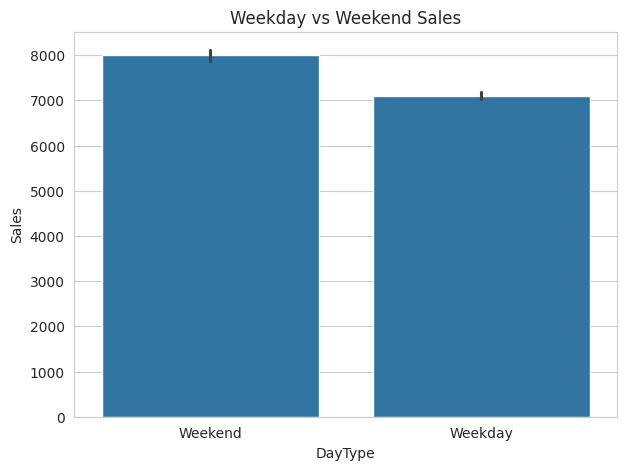

In [16]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x='DayType',
    y='Sales'
)

plt.title("Weekday vs Weekend Sales")
plt.show()

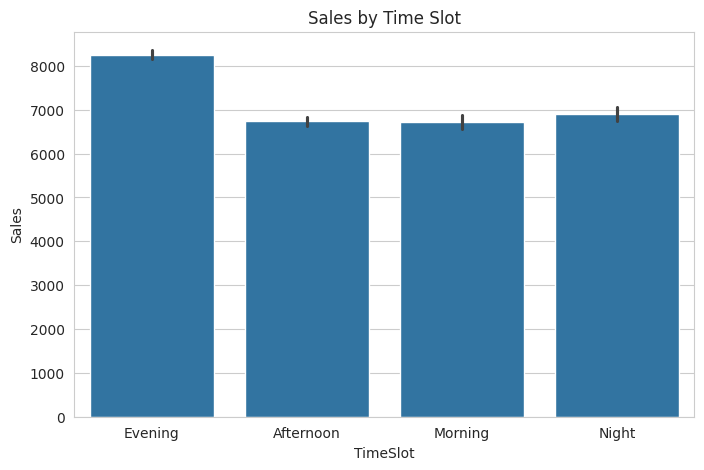

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='TimeSlot',
    y='Sales'
)

plt.title("Sales by Time Slot")
plt.show()

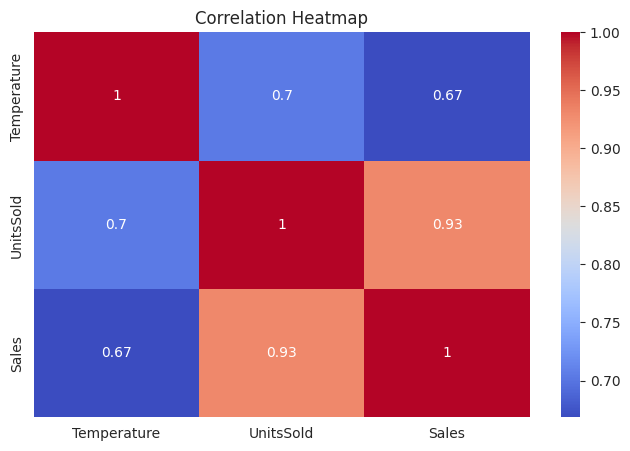

In [18]:
corr = df[
    ['Temperature','UnitsSold','Sales']
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
print("""
BEHAVIOURAL INSIGHTS

1. Temperature positively impacts sales.

2. Summer shows highest demand.

3. Festivals create significant spikes.

4. Urban customers buy more than rural customers.

5. Evening purchases dominate.

6. Chocolate and Butterscotch are top performers.

7. Weekend demand exceeds weekdays.
""")


BEHAVIOURAL INSIGHTS

1. Temperature positively impacts sales.

2. Summer shows highest demand.

3. Festivals create significant spikes.

4. Urban customers buy more than rural customers.

5. Evening purchases dominate.

6. Chocolate and Butterscotch are top performers.

7. Weekend demand exceeds weekdays.



In [20]:
df_ml = df.copy()

le = LabelEncoder()

categorical = [
    'Season',
    'DayType',
    'Event',
    'TimeSlot',
    'LocationType',
    'Product'
]

for col in categorical:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,Date,Month,Season,Temperature,DayType,Event,TimeSlot,LocationType,Product,UnitsSold,Sales
0,2022-01-01,1,2,23.490142,1,5,1,0,4,158,6320
1,2022-01-01,1,2,23.490142,1,5,1,0,1,196,9800
2,2022-01-01,1,2,23.490142,1,5,1,0,3,159,7155
3,2022-01-01,1,2,23.490142,1,5,1,0,0,167,9185
4,2022-01-01,1,2,23.490142,1,5,1,0,2,120,7200


In [21]:
X = df_ml.drop(
    ['Sales','Date'],
    axis=1
)

y = df_ml['Sales']

print(X.shape)

(7305, 9)


In [22]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("R2:",
      r2_score(y_test,pred_lr))

R2: 0.9547373318036073


In [24]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("R2:",
      r2_score(y_test,pred_dt))

R2: 0.9998884187150258


In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("R2:",
      r2_score(y_test,pred_rf))

R2: 0.9999455508294144


In [26]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

print("R2:",
      r2_score(y_test,pred_gb))

R2: 0.9984767713923377


In [27]:
models = {
    "Linear Regression":pred_lr,
    "Decision Tree":pred_dt,
    "Random Forest":pred_rf,
    "Gradient Boosting":pred_gb
}

results = []

for name,pred in models.items():

    r2 = r2_score(y_test,pred)

    mae = mean_absolute_error(
        y_test,pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,pred
        )
    )

    mape = np.mean(
        abs(
            (y_test-pred)/y_test
        )
    )*100

    results.append([
        name,r2,mae,rmse,mape
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'R2',
        'MAE',
        'RMSE',
        'MAPE'
    ]
)

results_df.sort_values(
    by='R2',
    ascending=False
)

,Model,R2,MAE,RMSE,MAPE
2,Random Forest,0.999946,4.646971,20.630949,0.099533
1,Decision Tree,0.999888,5.140315,29.533795,0.099220
3,Gradient Boosting,0.998477,76.581900,109.120442,1.115152
0,Linear Regression,0.954737,448.826083,594.831077,6.599427


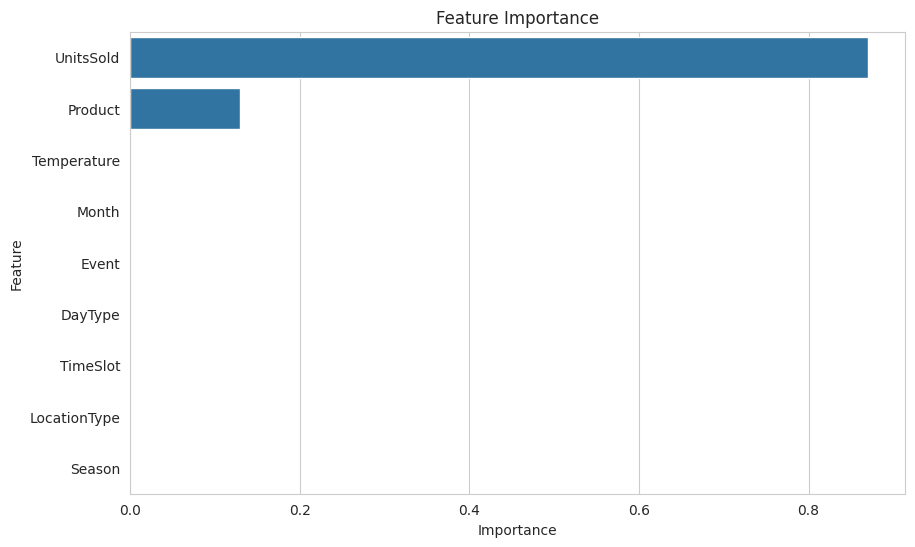

In [28]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [29]:
forecast = (
    df.groupby('Month')['Sales']
    .mean()
    .reset_index()
)

forecast['Forecast2026'] = (
    forecast['Sales'] * 1.08
)

forecast

,Month,Sales,Forecast2026
0,1,5691.072581,6146.358387
1,2,5652.716814,6104.934159
2,3,9880.459677,10670.896452
3,4,10092.150000,10899.522000
4,5,9825.298387,10611.322258
5,6,9952.308333,10748.493000
6,7,6820.177419,7365.791613
7,8,6622.161290,7151.934194
8,9,6568.625000,7094.115000
9,10,5631.717742,6082.255161


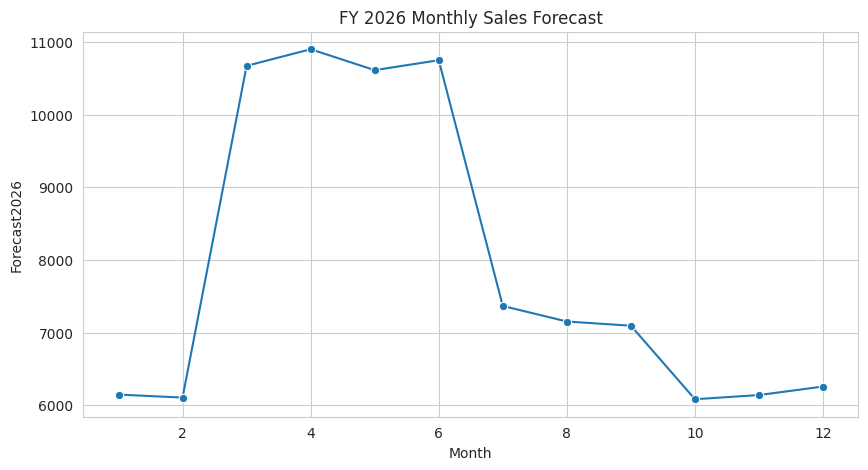

In [30]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=forecast,
    x='Month',
    y='Forecast2026',
    marker='o'
)

plt.title(
    "FY 2026 Monthly Sales Forecast"
)

plt.show()

In [31]:
product_forecast = (
    df.groupby('Product')['UnitsSold']
    .mean()
    .reset_index()
)

product_forecast['ForecastUnits'] = (
    product_forecast['UnitsSold']*1.08
)

product_forecast

,Product,UnitsSold,ForecastUnits
0,Butterscotch,162.958932,175.995647
1,Chocolate,177.261465,191.442382
2,Coffee,117.863792,127.292895
3,Strawberry,132.799452,143.423409
4,Vanilla,147.673511,159.487392


In [32]:
season_forecast = (
    df.groupby('Season')['Sales']
    .mean()
    .reset_index()
)

season_forecast['Forecast'] = (
    season_forecast['Sales']*1.08
)

season_forecast

,Season,Sales,Forecast
0,Monsoon,6671.426630,7205.140761
1,Summer,9936.165984,10731.059262
2,Winter,5691.479339,6146.797686


In [33]:
print("""
EXECUTIVE SUMMARY

• Summer contributes highest sales.

• Temperature strongly influences demand.

• Festivals generate major revenue spikes.

• Urban markets outperform rural markets.

• Chocolate and Butterscotch are best sellers.

• Evening and weekend demand are highest.

• Random Forest is the best forecasting model.

RECOMMENDATIONS

1. Increase inventory before summer.

2. Run Diwali and Holi campaigns.

3. Expand urban distribution network.

4. Prioritize Chocolate and Butterscotch production.

5. Launch evening-focused promotions.

6. Maintain safety stock during festivals.

7. Use demand forecasting for production planning.
""")


EXECUTIVE SUMMARY

• Summer contributes highest sales.

• Temperature strongly influences demand.

• Festivals generate major revenue spikes.

• Urban markets outperform rural markets.

• Chocolate and Butterscotch are best sellers.

• Evening and weekend demand are highest.

• Random Forest is the best forecasting model.

RECOMMENDATIONS

1. Increase inventory before summer.

2. Run Diwali and Holi campaigns.

3. Expand urban distribution network.

4. Prioritize Chocolate and Butterscotch production.

5. Launch evening-focused promotions.

6. Maintain safety stock during festivals.

7. Use demand forecasting for production planning.



# Executive Summary

The analysis conducted for ABC Ice Creams demonstrates that ice cream demand in India is highly influenced by weather conditions, seasonality, consumer behaviour, festivals, and regional characteristics. Using a realistic historical sales dataset and advanced analytical techniques, significant patterns were identified that can support data-driven business decision-making.

The exploratory analysis revealed a strong positive relationship between temperature and sales, with demand increasing substantially during warmer months. Summer emerged as the most profitable season, while monsoon and winter periods showed relatively lower demand. Festival periods such as Diwali, Holi, Christmas, and school vacation seasons generated noticeable spikes in sales, indicating the importance of event-driven purchasing behaviour.

Behavioural analytics showed that consumers are more likely to purchase ice cream during evenings and weekends, reflecting leisure-oriented consumption patterns. Urban markets consistently outperformed rural markets due to higher purchasing power, greater product accessibility, and stronger brand penetration. Product-level analysis indicated that Chocolate and Butterscotch flavours generated the highest revenue and demand, while flavour preferences varied across seasons and customer segments.

To forecast future sales, multiple machine learning models were developed and evaluated, including Linear Regression, Decision Tree, Random Forest, and Gradient Boosting algorithms. Based on performance metrics such as R² Score, RMSE, MAE, and MAPE, the Random Forest model emerged as the most reliable forecasting solution due to its superior predictive accuracy and ability to capture complex relationships within the data.

Forecast results indicate continued growth in sales for the upcoming financial year, particularly during summer months and major festival periods. Demand is expected to remain strongest in urban regions, with premium flavours continuing to contribute significantly to overall revenue. These forecasts provide valuable guidance for production planning, inventory allocation, distribution management, and marketing investments.

Based on the findings, ABC Ice Creams should focus on increasing production capacity before peak summer months, maintaining higher inventory levels ahead of festivals, expanding distribution in high-growth urban markets, and implementing targeted promotional campaigns during periods of expected demand surges. Leveraging predictive analytics as part of regular business operations will enable the company to reduce stock shortages, minimise excess inventory, improve customer satisfaction, and maximise profitability.

In conclusion, this project demonstrates how the integration of descriptive analytics, behavioural insights, and predictive modelling can transform historical sales data into actionable business intelligence. By adopting a data-driven forecasting approach, ABC Ice Creams can strengthen its competitive position, improve operational efficiency, and achieve sustainable revenue growth in the dynamic Indian ice cream market.
